<a href="https://colab.research.google.com/github/Utsav-Lal/Personal-Projects/blob/main/TD/TD_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

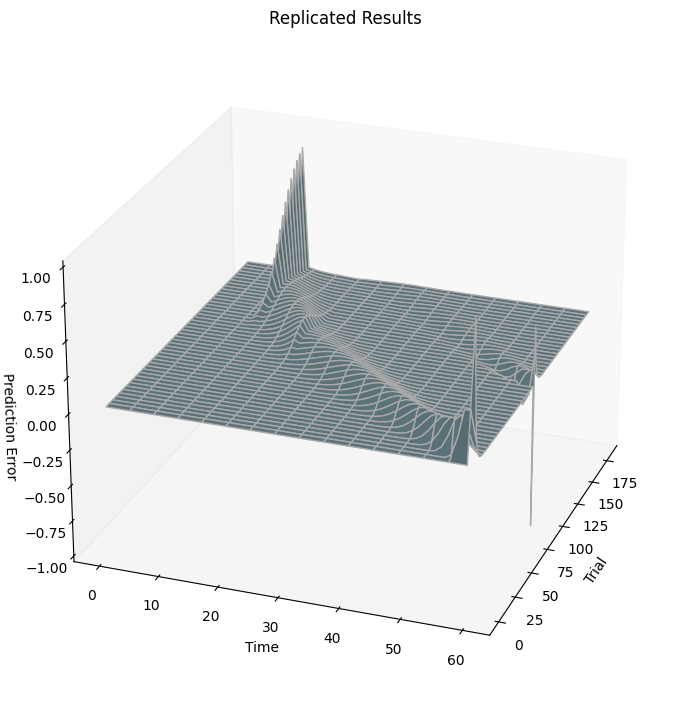

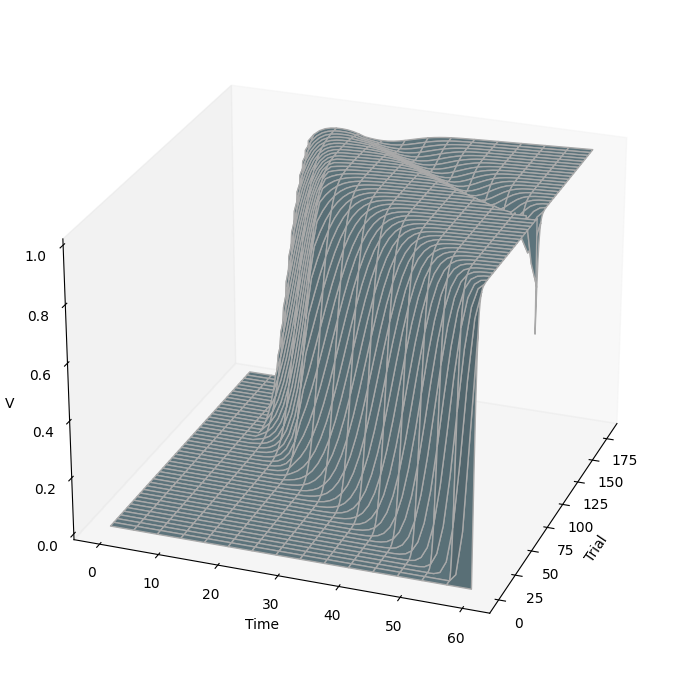

In [10]:
import numpy as np
a = 0.2  # learning rate
trials = 181  # Number of trials

# weights
wx = np.zeros(61)
wy = np.zeros(61)

# reward function
r = np.zeros(62)
r[60] = 1

# reward function when reward witheld
rbad = np.zeros(62)

g = 0.999  # gamma

# cue functions (x(t)_i = x[t, i])
x = np.zeros((62, 61))
x[np.arange(11, 62), np.arange(0, 51)] = 1
y = np.zeros((62, 61))
y[np.arange(21, 62), np.arange(0, 41)] = 1

d = np.zeros((trials, 61))  # error (trial x d(t))
Vhat = np.zeros((trials, 62))  # Vhat (trial x Vhat(t))
for trial in range(trials):
  Vhat[trial] = np.sum(wx*x+wy*y, axis=1)  # Calculate prediction from weights and cues

  if trial == trials//2:  # removes reward for one trial as in paper
    d[trial] = g*Vhat[trial, 1:]-Vhat[trial, :-1]+rbad[:-1]  # Calculates error
  else:
    d[trial] = g*Vhat[trial, 1:]-Vhat[trial, :-1]+r[:-1]  # Calculates Error

  # Update weights by functions from paper
  wx += a*np.sum(x[:-1, :]*d[trial].reshape((61, 1)), axis=0)
  wy += a*np.sum(y[:-1, :]*d[trial].reshape((61, 1)), axis=0)


# Graphing Code (Generated by Gemini)

# Graph error
import matplotlib.pyplot as plt
import numpy as np

data = d

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

trial = np.arange(trials)
time = np.arange(61)
Time, Trial = np.meshgrid(time, trial)

ax.plot_surface(
    Trial,
    Time,
    data,
    color="lightblue",
    edgecolor="darkgrey",
    linewidth=1,
    rstride = 4,
    cstride = 4,
)

ax.set_xlabel("Trial")
ax.set_ylabel("Time")
ax.set_zlabel("Prediction Error")

ax.view_init(elev=25, azim=-160)
ax.grid(False)
plt.gca().invert_yaxis()
plt.tight_layout()
ax.set_title("Replicated Results")
plt.show()


# Graph Vhat
data = Vhat[:,:-1]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

trial = np.arange(trials)
time = np.arange(61)
Time, Trial = np.meshgrid(time, trial)

ax.plot_surface(
    Trial,
    Time,
    data,
    color="lightblue",
    edgecolor="darkgrey",
    linewidth=1,
    rstride = 4,
    cstride = 4,
)

ax.set_xlabel("Trial")
ax.set_ylabel("Time")
ax.set_zlabel("V")

ax.view_init(elev=25, azim=-160)
ax.grid(False)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()








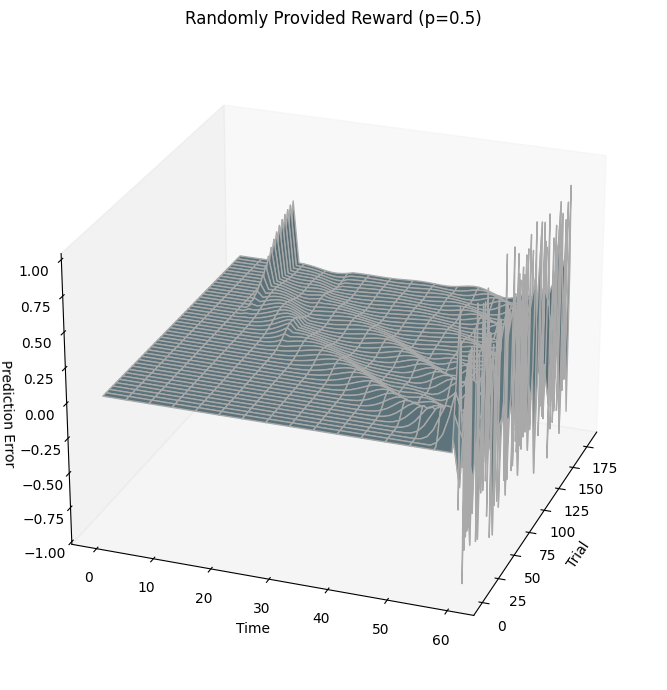

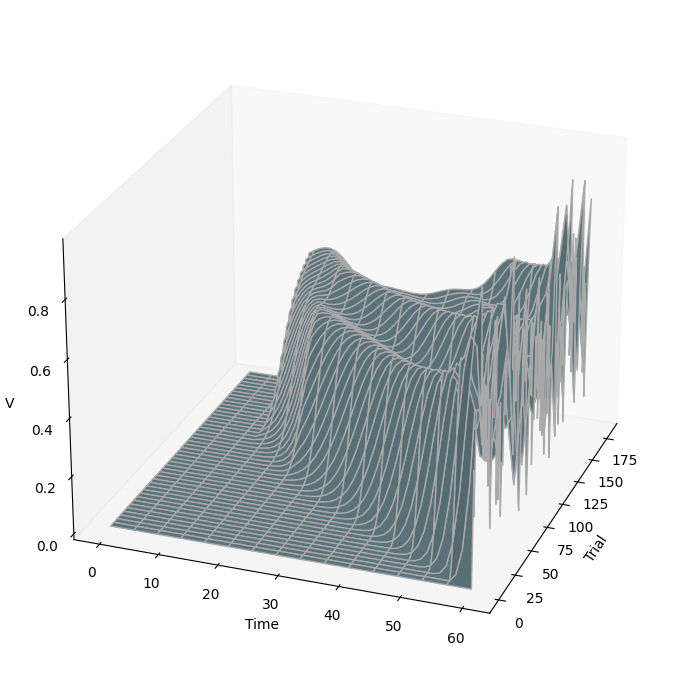

In [14]:
import numpy as np
a = 0.2  # learning rate
trials = 181  # Number of trials
p = 0.5 # probability that reward is witheld
np.random.seed(1)

# weights
wx = np.zeros(61)
wy = np.zeros(61)

# reward function
r = np.zeros(62)
r[60] = 1

# reward function when reward witheld
rbad = np.zeros(62)

g = 0.999  # gamma

# cue functions (x(t)_i = x[t, i])
x = np.zeros((62, 61))
x[np.arange(11, 62), np.arange(0, 51)] = 1
y = np.zeros((62, 61))
y[np.arange(21, 62), np.arange(0, 41)] = 1

d = np.zeros((trials, 61))  # error (trial x d(t))
Vhat = np.zeros((trials, 62))  # Vhat (trial x Vhat(t))
for trial in range(trials):
  Vhat[trial] = np.sum(wx*x+wy*y, axis=1)  # Calculate prediction from weights and cues

  if np.random.rand() >= p:  # removes reward with probability 1-p
    d[trial] = g*Vhat[trial, 1:]-Vhat[trial, :-1]+rbad[:-1]  # Calculates error
  else:
    d[trial] = g*Vhat[trial, 1:]-Vhat[trial, :-1]+r[:-1]  # Calculates Error

  # Update weights by functions from paper
  wx += a*np.sum(x[:-1, :]*d[trial].reshape((61, 1)), axis=0)
  wy += a*np.sum(y[:-1, :]*d[trial].reshape((61, 1)), axis=0)


# Graphing Code (Generated by Gemini)

# Graph error
import matplotlib.pyplot as plt
import numpy as np

data = d

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

trial = np.arange(trials)
time = np.arange(61)
Time, Trial = np.meshgrid(time, trial)

ax.plot_surface(
    Trial,
    Time,
    data,
    color="lightblue",
    edgecolor="darkgrey",
    linewidth=1,
    rstride = 4,
    cstride = 4,
)

ax.set_xlabel("Trial")
ax.set_ylabel("Time")
ax.set_zlabel("Prediction Error")

ax.view_init(elev=25, azim=-160)
ax.grid(False)
plt.gca().invert_yaxis()
ax.set_title("Randomly Provided Reward (p=0.5)")
plt.tight_layout()
plt.show()


# Graph Vhat
data = Vhat[:,:-1]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

trial = np.arange(trials)
time = np.arange(61)
Time, Trial = np.meshgrid(time, trial)

ax.plot_surface(
    Trial,
    Time,
    data,
    color="lightblue",
    edgecolor="darkgrey",
    linewidth=1,
    rstride = 4,
    cstride = 4,
)

ax.set_xlabel("Trial")
ax.set_ylabel("Time")
ax.set_zlabel("V")

ax.view_init(elev=25, azim=-160)
ax.grid(False)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()








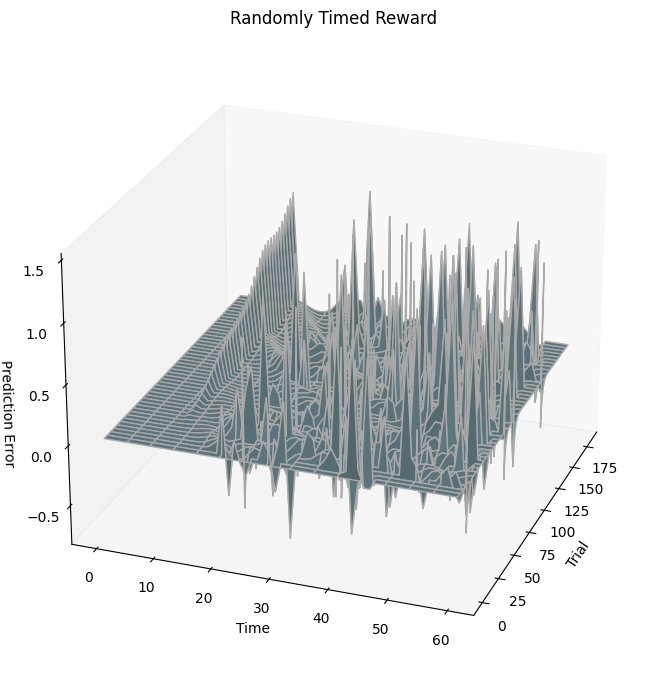

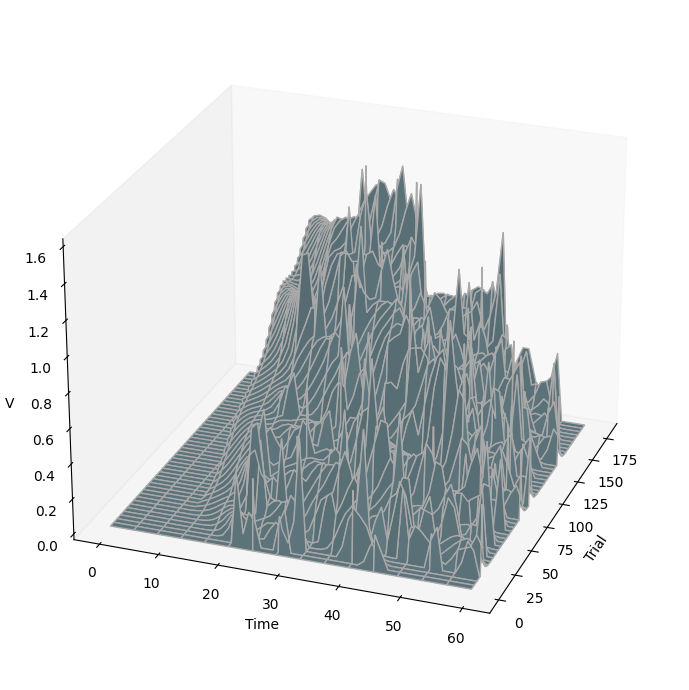

In [15]:
import numpy as np
a = 0.2  # learning rate
trials = 181  # Number of trials
np.random.seed(3)

# weights
wx = np.zeros(61)
wy = np.zeros(61)

# reward function
r = np.zeros(62)
r[60] = 1

# reward function when reward witheld
rbad = np.zeros(62)
rbad[30] = 1

g = 0.999  # gamma

# cue functions (x(t)_i = x[t, i])
x = np.zeros((62, 61))
x[np.arange(11, 62), np.arange(0, 51)] = 1
y = np.zeros((62, 61))
y[np.arange(21, 62), np.arange(0, 41)] = 1

d = np.zeros((trials, 61))  # error (trial x d(t))
Vhat = np.zeros((trials, 62))  # Vhat (trial x Vhat(t))
for trial in range(trials):
  Vhat[trial] = np.sum(wx*x+wy*y, axis=1)  # Calculate prediction from weights and cues

  # generates a random reward time
  r = np.zeros(62)
  r[np.random.choice(np.arange(21, 62))] = 1

  d[trial] = g*Vhat[trial, 1:]-Vhat[trial, :-1]+r[:-1]  # Calculates Error

  # Update weights by functions from paper
  wx += a*np.sum(x[:-1, :]*d[trial].reshape((61, 1)), axis=0)
  wy += a*np.sum(y[:-1, :]*d[trial].reshape((61, 1)), axis=0)


# Graphing Code (Generated by Gemini)

# Graph error
import matplotlib.pyplot as plt
import numpy as np

data = d

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

trial = np.arange(trials)
time = np.arange(61)
Time, Trial = np.meshgrid(time, trial)

ax.plot_surface(
    Trial,
    Time,
    data,
    color="lightblue",
    edgecolor="darkgrey",
    linewidth=1,
    rstride = 4,
    cstride = 4,
)

ax.set_xlabel("Trial")
ax.set_ylabel("Time")
ax.set_zlabel("Prediction Error")

ax.view_init(elev=25, azim=-160)
ax.grid(False)
plt.gca().invert_yaxis()
ax.set_title("Randomly Timed Reward")
plt.tight_layout()
plt.show()


# Graph Vhat
data = Vhat[:,:-1]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

trial = np.arange(trials)
time = np.arange(61)
Time, Trial = np.meshgrid(time, trial)

ax.plot_surface(
    Trial,
    Time,
    data,
    color="lightblue",
    edgecolor="darkgrey",
    linewidth=1,
    rstride = 4,
    cstride = 4,
)

ax.set_xlabel("Trial")
ax.set_ylabel("Time")
ax.set_zlabel("V")

ax.view_init(elev=25, azim=-160)
ax.grid(False)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()






